In [1]:
import sys

sys.path.append("..")


from src.plotting.feature_plotting import plot_graph
import matplotlib.pyplot as plt
import numpy as np
import torch

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_with_layer_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_with_layer_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)

In [2]:
import src.torch.pre_processing.graph_batching as graph_batching
from importlib import reload

reload(graph_batching)

graph_builder = graph_batching.CombinedGraphBuilder(
    connect_layers=True, mppc_timing_cutoff=0.1
)
hetero_builder = graph_batching.HeteroGraphBuilder(
    connect_layers=True, mppc_timing_cutoff=0.1
)
layer_hetero_builder = graph_batching.LayerSeparatedHeteroGraphBuilder(
    connect_layers=True, mppc_timing_cutoff=0.1
)
event_processor = graph_batching.EventProcessor(graph_builder=graph_builder)
hetero_event_processor = graph_batching.EventProcessor(graph_builder=hetero_builder)
layer_hetero_event_processor = graph_batching.EventProcessor(
    graph_builder=layer_hetero_builder
)

Event has 19 MPPC hits and 10 Pixel hits


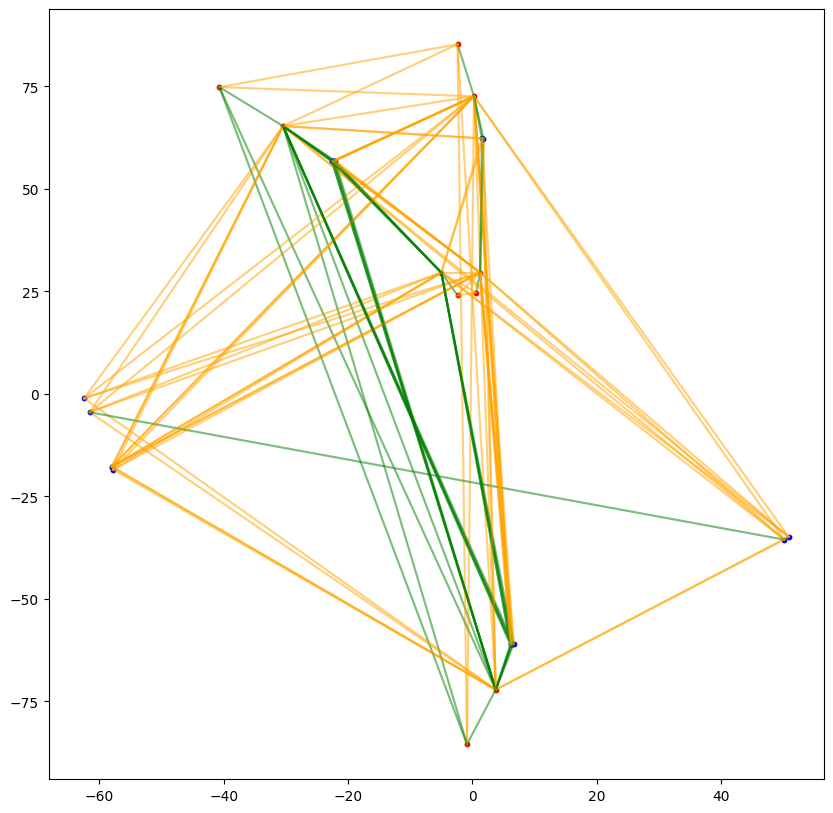

In [3]:
event_id = 1
graphs_bg = event_processor.process_single_event(
    X_pixel=sig_pixel_spacetime[event_id],
    X_mppc=sig_mppc_spacetime[event_id],
    labels=None,
)

fig, ax = plt.subplots(1, figsize=(10, 10))
graph = graphs_bg[2]
mppc_nodes = graph.x[graph.x[:, 3] == 0]
pixel_nodes = graph.x[graph.x[:, 3] == 1]
ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c="blue", s=10, label="MPPC hits")
ax.scatter(pixel_nodes[:, 0], pixel_nodes[:, 1], c="red", s=10, label="Pixel hits")
for edge_index in range(graph.edge_index.shape[1]):
    edge = graph.edge_index[:, edge_index]
    if graph.edge_labels[edge_index] == 1:
        color = "green"
    else:
        color = "orange"
    ax.plot(
        [graph.x[edge[0], 0], graph.x[edge[1], 0]],
        [graph.x[edge[0], 1], graph.x[edge[1], 1]],
        c=color,
        alpha=0.3,
    )
print(
    f"Event has {(graph.x[:, 3] == 0).sum()} MPPC hits and {(graph.x[:, 3] == 1).sum()} Pixel hits"
)

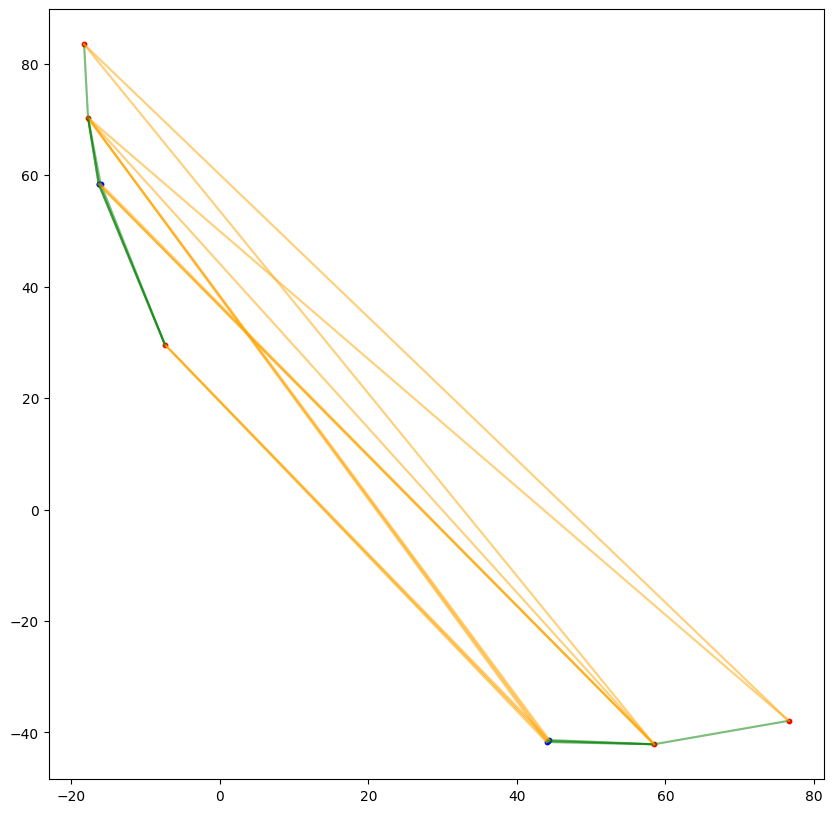

In [4]:
event_id = 0
graphs_bg = hetero_event_processor.process_single_event(
    X_pixel=sig_only_pixel_spacetime[event_id],
    X_mppc=sig_only_mppc_spacetime[event_id],
    labels=None,
)
graphs_bg[0]
fig, ax = plt.subplots(1, figsize=(10, 10))
graph = graphs_bg[0]
mppc_nodes = graph.x_dict["mppc"]
pixel_nodes = graph.x_dict["pixel"]
ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c="blue", s=10, label="MPPC hits")
ax.scatter(pixel_nodes[:, 0], pixel_nodes[:, 1], c="red", s=10, label="Pixel hits")
for edge_type, edge_index in graph.edge_index_dict.items():
    src, _, dst = edge_type
    for edge_idx in range(edge_index.shape[1]):
        edge = edge_index[:, edge_idx]
        if graph.edge_labels_dict[edge_type][edge_idx] == 1:
            color = "green"
        else:
            color = "orange"
        ax.plot(
            [
                graph.x_dict[edge_type[0]][edge[0], 0],
                graph.x_dict[edge_type[2]][edge[1], 0],
            ],
            [
                graph.x_dict[edge_type[0]][edge[0], 1],
                graph.x_dict[edge_type[2]][edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )

In [10]:
event_id = 1
layer_graphs_bg = layer_hetero_event_processor.process_single_event(
    X_pixel=sig_only_pixel_spacetime[event_id],
    X_mppc=sig_only_mppc_spacetime[event_id],
    labels=None,
)

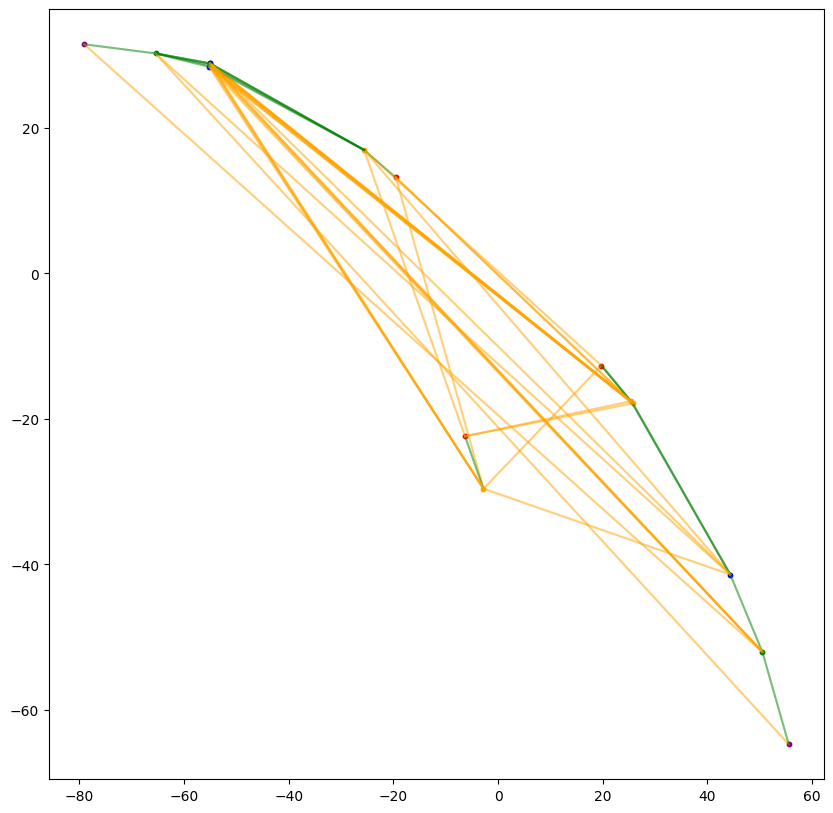

In [6]:
layer_graphs_bg[0]
fig, ax = plt.subplots(1, figsize=(10, 10))
graph = layer_graphs_bg[0]
mppc_nodes = graph.x_dict["mppc"]
layer_1_nodes = graph.x_dict["layer_1"]
layer_2_nodes = graph.x_dict["layer_2"]
layer_3_nodes = graph.x_dict["layer_3"]
layer_4_nodes = graph.x_dict["layer_4"]
ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c="blue", s=10, label="MPPC hits")
ax.scatter(
    layer_1_nodes[:, 0], layer_1_nodes[:, 1], c="red", s=10, label="Layer 1 Pixel hits"
)
ax.scatter(
    layer_2_nodes[:, 0],
    layer_2_nodes[:, 1],
    c="orange",
    s=10,
    label="Layer 2 Pixel hits",
)
ax.scatter(
    layer_3_nodes[:, 0],
    layer_3_nodes[:, 1],
    c="green",
    s=10,
    label="Layer 3 Pixel hits",
)
ax.scatter(
    layer_4_nodes[:, 0],
    layer_4_nodes[:, 1],
    c="purple",
    s=10,
    label="Layer 4 Pixel hits",
)
for edge_type, edge_index in graph.edge_index_dict.items():
    src, _, dst = edge_type
    for edge_idx in range(edge_index.shape[1]):
        edge = edge_index[:, edge_idx]
        if graph.edge_labels_dict[edge_type][edge_idx] == 1:
            color = "green"
        else:
            color = "orange"
        ax.plot(
            [
                graph.x_dict[edge_type[0]][edge[0], 0],
                graph.x_dict[edge_type[2]][edge[1], 0],
            ],
            [
                graph.x_dict[edge_type[0]][edge[0], 1],
                graph.x_dict[edge_type[2]][edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )

In [29]:

def plot_detector(ax):
    layer_1_circle = plt.Circle((0, 0), 23, color="red", fill=False, linestyle="dashed", alpha = 0.5)
    layer_2_circle = plt.Circle((0, 0), 29.5, color="red", fill=False, linestyle="dashed", alpha = 0.5)
    scifi_layer_circle = plt.Circle((0, 0), 61, color="blue", fill=False, linewidth=10, alpha = 0.5)
    layer_3_circle = plt.Circle((0, 0), 72, color="red", fill=False, linestyle="dashed", alpha = 0.5)
    layer_4_circle = plt.Circle((0, 0), 86, color="red", fill=False, linestyle="dashed", alpha = 0.5)


    ax.set_xlim(-90, 90)
    ax.set_ylim(-90, 90)
    ax.add_patch(layer_1_circle)
    ax.add_patch(layer_2_circle)
    ax.add_patch(scifi_layer_circle)
    ax.add_patch(layer_3_circle)
    ax.add_patch(layer_4_circle)
    ax.scatter(0, 0, c="black", s=50, label="Target position")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # hide spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

def plot_graph_to_axis(ax, graph, no_edges = False):
    mppc_nodes = graph["mppc"].x
    pixel_nodes = np.concatenate(
        [
            graph["layer_1"].x,
            graph["layer_2"].x,
            graph["layer_3"].x,
            graph["layer_4"].x,
        ],
        axis=0,
    )
    ax.scatter(mppc_nodes[:, 0], mppc_nodes[:, 1], c="blue", s=20, label="MPPC hits")
    ax.scatter(pixel_nodes[:, 0], pixel_nodes[:, 1], c="red", s=20, label="Pixel hits")
    if no_edges:
        return
    layer_1_to_layer_2_edges = graph["layer_1", "to", "layer_2"]
    for edge_idx in range(layer_1_to_layer_2_edges.edge_index.shape[1]):
        if layer_1_to_layer_2_edges.edge_labels[edge_idx] != 1:
            color = "orange"
        else:
            color = "green"

        edge = layer_1_to_layer_2_edges.edge_index[:, edge_idx]
        ax.plot(
            [
                graph["layer_1"].x[edge[0], 0],
                graph["layer_2"].x[edge[1], 0],
            ],
            [
                graph["layer_1"].x[edge[0], 1],
                graph["layer_2"].x[edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )
    layer_2_to_mppc_edges = graph["layer_2", "to", "mppc"]
    for edge_idx in range(layer_2_to_mppc_edges.edge_index.shape[1]):
        if layer_2_to_mppc_edges.edge_labels[edge_idx] != 1:
            color="orange"
        else:
            color="green"
        edge = layer_2_to_mppc_edges.edge_index[:, edge_idx]
        ax.plot(
            [
                graph["layer_2"].x[edge[0], 0],
                graph["mppc"].x[edge[1], 0],
            ],
            [
                graph["layer_2"].x[edge[0], 1],
                graph["mppc"].x[edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )
    mppc_to_layer_3_edges = graph["mppc", "to", "layer_3"]
    for edge_idx in range(mppc_to_layer_3_edges.edge_index.shape[1]):
        if mppc_to_layer_3_edges.edge_labels[edge_idx] != 1:
            color="orange"
        else:
            color="green"
        edge = mppc_to_layer_3_edges.edge_index[:, edge_idx]
        ax.plot(
            [
                graph["mppc"].x[edge[0], 0],
                graph["layer_3"].x[edge[1], 0],
            ],
            [
                graph["mppc"].x[edge[0], 1],
                graph["layer_3"].x[edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )
    layer_3_to_layer_4_edges = graph["layer_3", "to", "layer_4"]
    for edge_idx in range(layer_3_to_layer_4_edges.edge_index.shape[1]):
        if layer_3_to_layer_4_edges.edge_labels[edge_idx] != 1:
            color="orange"
        else:
            color="green"
        edge = layer_3_to_layer_4_edges.edge_index[:, edge_idx]
        ax.plot(
            [
                graph["layer_3"].x[edge[0], 0],
                graph["layer_4"].x[edge[1], 0],
            ],
            [
                graph["layer_3"].x[edge[0], 1],
                graph["layer_4"].x[edge[1], 1],
            ],
            c=color,
            alpha=0.3,
        )

In [ ]:
event_id = 25
graphs_bg = layer_hetero_event_processor.process_single_event(
    X_pixel=bg_pixel_spacetime[event_id],
    X_mppc=bg_mppc_spacetime[event_id],
    labels=None,
)

while len(graphs_bg) != 4:
    graphs_bg = layer_hetero_event_processor.process_single_event(
        X_pixel=bg_pixel_spacetime[event_id],
        X_mppc=bg_mppc_spacetime[event_id],
        labels=None,
    )
    event_id += 1




fig, ax = plt.subplots(1, figsize=(10, 10))
plot_detector(ax)
for graph in graphs_bg:
    plot_graph_to_axis(ax, graph, no_edges=True)
fig.savefig(
    f"{PLOTS_DIR}/event_{event_id}_graph_layer_hetero_no_edges.svg",
    bbox_inches="tight",
    dpi=300,
)
plt.close(fig)

fig, ax = plt.subplots(1, figsize=(10, 10))
plot_detector(ax)
for graph in graphs_bg:
    plot_graph_to_axis(ax, graph)
fig.savefig(
    f"{PLOTS_DIR}/event_{event_id}_graph_layer_hetero.svg",
    bbox_inches="tight",
    dpi=300,
)
plt.close(fig)
for graph_id,graph in enumerate(graphs_bg):
    fig, ax = plt.subplots(1, figsize=(10, 10))
    plot_detector(ax)
    plot_graph_to_axis(ax, graph)

    fig.savefig(
        f"{PLOTS_DIR}/event_{event_id}_graph_{graph_id}_layer_hetero.svg",
        bbox_inches="tight",
        dpi=300,
    )
    plt.close(fig)



: 

In [ ]:
graphs_bg

In [ ]:
graphs_bg[0]["layer_1"]